# Inciso 4
## Grupo 2

### Librerías

In [1]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

### Fechas

In [2]:
fechas_amatitlan = [
    "2025-01-28",
    "2025-04-15",
    "2025-04-28",
    "2025-11-24",
    "2026-01-08",
    "2026-02-02",
    "2026-02-07",
    "2026-03-29",
    "2026-04-13",
    "2026-04-28",
    "2026-06-19"
]

fechas_atitlan = [
    "2025-01-18",
    "2025-04-13",
    "2025-05-13",
    "2025-07-17",
    "2025-11-21",
    "2025-12-29",
    "2026-02-12",
    "2026-03-24",
    "2026-04-13",
    "2026-04-28",
    "2026-07-22"
]

### Función promedio de cianobacteria.

In [3]:
def promedio_cianobacteria(ruta_raster):

    with rasterio.open(ruta_raster) as src:
        
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan

        data[~np.isfinite(data)] = np.nan
        promedio = np.nanmean(data)

    return promedio

### Procesamiento en todas las fechas.

In [4]:
def procesar_lago(nombre_lago, carpeta, fechas, nombre):
    resultados = []

    for fecha in fechas:
        ruta = Path(carpeta) / f"{nombre}_{fecha}_indices.tif"

        promedio = promedio_cianobacteria(ruta)

        resultados.append({
            "lago": nombre_lago,
            "fecha": fecha,
            "cyano_promedio": promedio
        })
        
    return pd.DataFrame(resultados)

### 4.1) Creación de DataFrames, con índice promedio.

In [5]:
df_amatitlan = procesar_lago(nombre_lago="Amatitlán", carpeta="data/amatitlan", fechas=fechas_amatitlan, nombre='amatitlan')
df_atitlan = procesar_lago(nombre_lago="Atitlán", carpeta="data/atitlan", fechas=fechas_atitlan, nombre='atitlan')

df = pd.concat([df_amatitlan, df_atitlan], ignore_index=True)
df["fecha"] = pd.to_datetime(df["fecha"])

### 4.2) Evolución temporal Amatitlán.

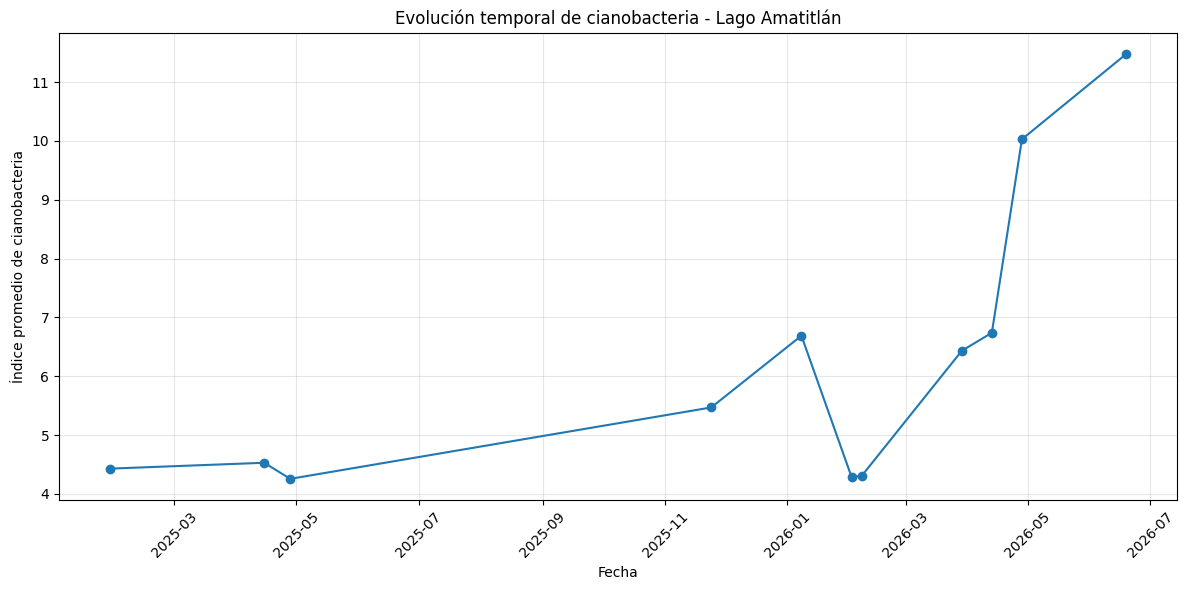

In [6]:
df_amatitlan["fecha"] = pd.to_datetime(df_amatitlan["fecha"])

plt.figure(figsize=(12, 6))
plt.plot(df_amatitlan["fecha"], df_amatitlan["cyano_promedio"], marker="o")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio de cianobacteria")
plt.title("Evolución temporal de cianobacteria - Lago Amatitlán")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2) Evolución temporal Atitlán.

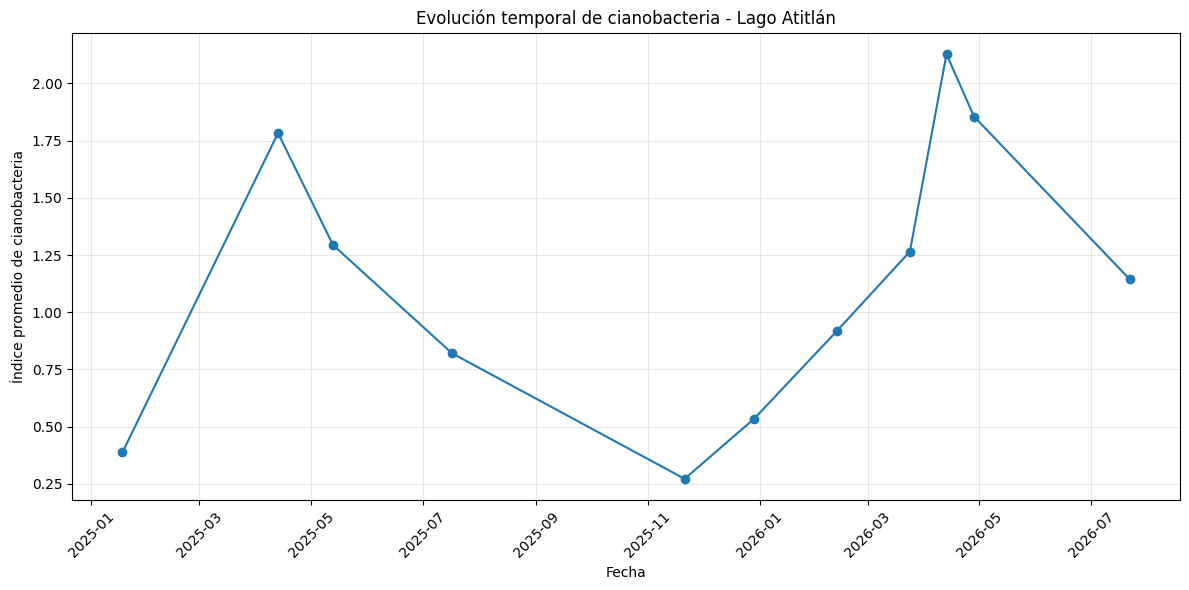

In [7]:
df_atitlan["fecha"] = pd.to_datetime(df_atitlan["fecha"])

plt.figure(figsize=(12, 6))

plt.plot(df_atitlan["fecha"], df_atitlan["cyano_promedio"], marker="o")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio de cianobacteria")
plt.title("Evolución temporal de cianobacteria - Lago Atitlán")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3) Identificación de picos.

In [8]:
top_amatitlan = (df_amatitlan.sort_values("cyano_promedio", ascending=False).head(3))
top_atitlan = (df_atitlan.sort_values("cyano_promedio", ascending=False).head(3))

In [9]:
top_amatitlan

,lago,fecha,cyano_promedio
10,Amatitlán,2026-06-19,11.474802
9,Amatitlán,2026-04-28,10.026723
8,Amatitlán,2026-04-13,6.738171


In [10]:
top_atitlan

,lago,fecha,cyano_promedio
8,Atitlán,2026-04-13,2.128609
9,Atitlán,2026-04-28,1.855590
1,Atitlán,2025-04-13,1.783338


### Picos de Amatitlán.

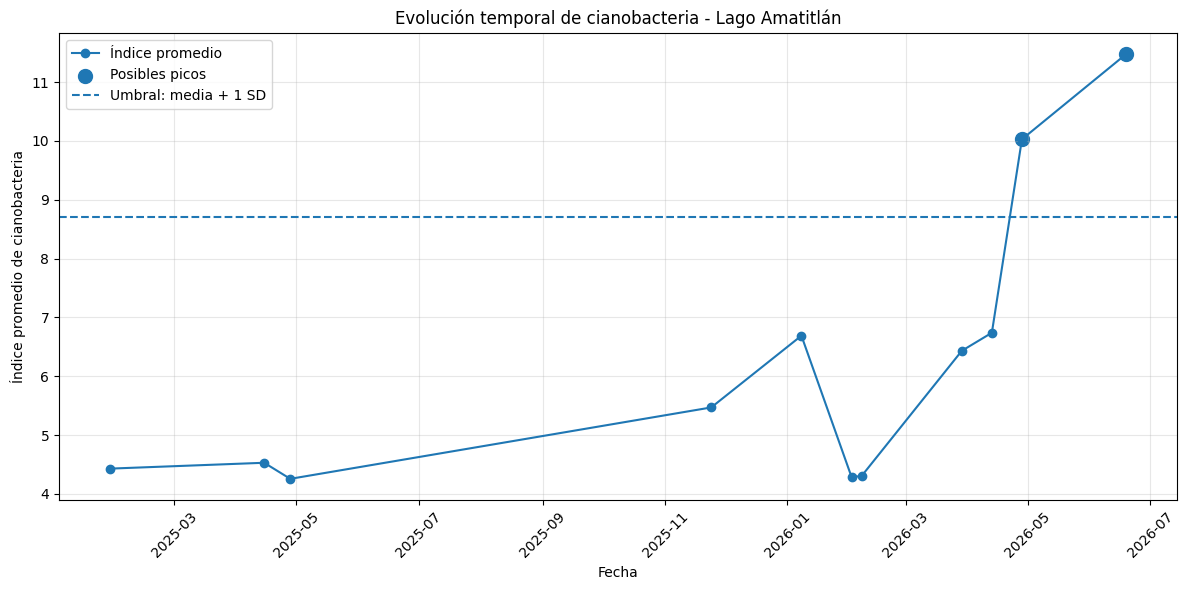

In [11]:
media = df_amatitlan["cyano_promedio"].mean()
std = df_amatitlan["cyano_promedio"].std()
umbral = media + std
picos = df_amatitlan[df_amatitlan["cyano_promedio"] > umbral]

plt.figure(figsize=(12, 6))

plt.plot(df_amatitlan["fecha"], df_amatitlan["cyano_promedio"], marker="o", label="Índice promedio")
plt.scatter(picos["fecha"], picos["cyano_promedio"], s=100, label="Posibles picos")
plt.axhline(umbral, linestyle="--", label="Umbral: media + 1 SD")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio de cianobacteria")
plt.title("Evolución temporal de cianobacteria - Lago Amatitlán")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Picos de Atitlán.

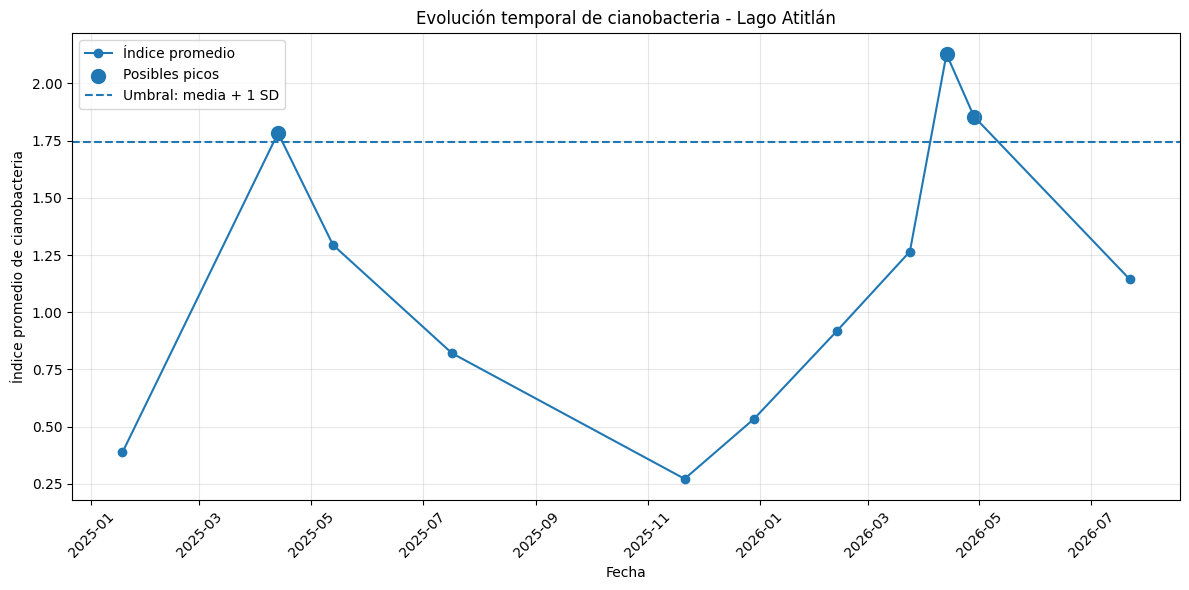

In [12]:
media = df_atitlan["cyano_promedio"].mean()
std = df_atitlan["cyano_promedio"].std()
umbral = media + std
picos = df_atitlan[df_atitlan["cyano_promedio"] > umbral]

plt.figure(figsize=(12, 6))

plt.plot(df_atitlan["fecha"], df_atitlan["cyano_promedio"], marker="o", label="Índice promedio")
plt.scatter(picos["fecha"], picos["cyano_promedio"], s=100, label="Posibles picos")
plt.axhline(umbral, linestyle="--", label="Umbral: media + 1 SD")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio de cianobacteria")
plt.title("Evolución temporal de cianobacteria - Lago Atitlán")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4.4 Interpretación.

En el lago de Atitlán se tiene problemas en el mes de abril, lo cual puede indicar que se debe a la Semana Santa.  
El lago de Amatitlán tiene un índice más alto que el de Atitlán, no se observa el mismo problema de la Semana Santa, pero en los últimos meses ha tenido un aumento signficativo en sus índices. En el link siguiente se obtiene una explicación del aumento debido a las lluvias fuertes durante esa época.  
https://www.prensalibre.com/guatemala/por-que-recomiendan-no-sumergirse-en-el-lago-de-atitlan-amsclae-alerta-por-cianobacterias/